In [2]:
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple, Dict, Callable, Union
import time
from sklearn.linear_model import LinearRegression

In [3]:
def split(t: np.ndarray)-> Tuple[np.ndarray, int, np.ndarray]:
    try:
        pivot = t[0]
        a=[]
        b=[]
        for i in range(1,len(t)):
            if t[0]>t[i]:
                a.append(t[i])
            else:
                b.append(t[i])
    except: 
        print("Errror in fucnt split")
    else:
        return (a,pivot,b)

In [4]:
t=[4,6,2,3,7,1,8]
print(split(t))

([2, 3, 1], 4, [6, 7, 8])


In [5]:
def qsel(t: np.ndarray, k: int)-> Union[int, None]:
    try:
        if len(t)==1 and k==0:
            return t[0]
        a,mid,b=split(t)
        
        if (k==len(a)):
            return mid
        if (k<len(a)):
            return qsel(a,k)
        elif(k>len(a)):
            return qsel(b,k-len(a)-1)
        return 
    except:
        print("Error in funct qsel")

In [6]:
t=[4,6,2,3,7,1,8]
print(qsel(t,4))

6


In [7]:
def qsel_nr(t: np.ndarray, k: int)-> Union[int, None]:
    aux=t.copy()
    try:
        while len(aux)>0:
            if (len(aux)==1 and k==0):
                return aux[0]

            a,mid,b=split(aux)

            if (k==len(a)):
                return mid
            elif (k<len(a)):
                aux=a
            elif(k>len(a)):
                aux=b
                k-=(len(a)+1)
        return
    except:
        print("Error in funct qsel_nr")

In [8]:
t=[4,6,2,3,7,1,8]
print(qsel_nr(t,4))

6


In [9]:
t=list(range(11))[ : : -1]
t= np.random.permutation(11)
shift = 0
for k in range(len(t)):
    print(k, qsel(t, k+shift))
    print(k, qsel_nr(t, k+shift))

0 0

0 0

1 1

1 1

2 2

2 2

3 3

3 3

4 4

4 4

5 5

5 5

6 6

6 6

7 7

7 7

8 8

8 8

9 9

9 9

10 10

10 10


In [10]:
def split_pivot(t: np.ndarray, mid: int)-> Tuple[np.ndarray, int, np.ndarray]:
    try:
        t_l = [u for u in t if u < mid]
        t_r = [u for u in t if u > mid]
    except:
        print("Error in funct split_pivot")
    else:
        return (t_l, mid, t_r)

In [13]:
arr=[3, 2, 1, 4]
print(pivot5(arr))
print(split_pivot(arr,pivot5(arr)))

3

([2, 1], 3, [4])


In [12]:
def pivot5(t: np.ndarray)-> int:
    try:
        if(len(t)>5):
            ngroups = len(t) // 5
            indicemed = 5 // 2 

            sublistas =  [t[i:i+ 5] for i in range(0, len(t), 5)][:ngroups]

            medianas = [sorted(sub)[indicemed] for sub in sublistas]

            if len(medianas) <= 5:
                pivote = sorted(medianas)[len(medianas)//2]
            else:
                pivote = qsel5_nr(medianas, len(medianas)//2)
            return pivote
        else:
            return np.sort(t)[len(t)//2]
    except:
        print("Error in funct pivot5")


In [14]:
def qsel5_nr(t: np.ndarray, k: int)-> int:
    if k >= len(t) or k < 0:
        return
    
    try:
        tt = t.copy()
        while len(tt) > 5:
            mid = pivot5(np.array(tt))

            t_l, mid, t_r = split_pivot(tt, mid)
            m = len(t_l)

            if k == m:
                return int(mid)
            elif k < m:
                tt = t_l
            else:
                tt = t_r
                k = k-m-1

        if len(tt) <= 5:
            return int(np.sort(tt)[k])
    except:
        print("Error in funct qsel5_nr")

In [15]:
arr = [ 10, 4, 5]
n = len(arr)
k = 2
print(qsel5_nr(arr, k))

10


In [16]:
t=list(range(9))[ : : -1]
t= np.random.permutation(11)
shift = 0
for k in range(len(t)):
    print(k, qsel5_nr(t, k))

0 0

1 1

2 2

3 3

4 4

5 5

6 6

7 7

8 8

9 9

10 10


In [17]:
def qsort_5(t: np.ndarray)-> np.ndarray:
    if len(t)==0:
        return np.array([])
    aux= t.copy()
    
    try:
        t_l, mid, t_r = split_pivot(aux, pivot5(aux))
        if(len(t_l)>1):
            t_l=qsort_5(t_l)
        if(len(t_r)>1):
            t_r=qsort_5(t_r)

        t_l=np.append(t_l, np.array([mid]))
    except:
        print("Error in funct qsort_5")
    else:
        return np.append(t_l,t_r)


In [18]:
arr=[3,5,2,6,7,1,8,10,9,4]
print(qsort_5(arr))

[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]


50

100

150

200

250

300

350

400

450

500

550

600

650

700

750

800

850

900

950

1000

[[5.00000000e+01 8.34308380e-04]

 [1.00000000e+02 1.04279580e-03]

 [1.50000000e+02 1.54481212e-03]

 [2.00000000e+02 1.80733652e-03]

 [2.50000000e+02 2.32511370e-03]

 [3.00000000e+02 2.87274604e-03]

 [3.50000000e+02 3.29369132e-03]

 [4.00000000e+02 3.83218838e-03]

 [4.50000000e+02 4.73942038e-03]

 [5.00000000e+02 4.95689406e-03]

 [5.50000000e+02 5.56898266e-03]

 [6.00000000e+02 6.33295168e-03]

 [6.50000000e+02 6.80280934e-03]

 [7.00000000e+02 7.04860976e-03]

 [7.50000000e+02 7.54097280e-03]

 [8.00000000e+02 8.77210114e-03]

 [8.50000000e+02 9.01111576e-03]

 [9.00000000e+02 9.37682760e-03]

 [9.50000000e+02 9.87866358e-03]

 [1.00000000e+03 1.07858046e-02]]


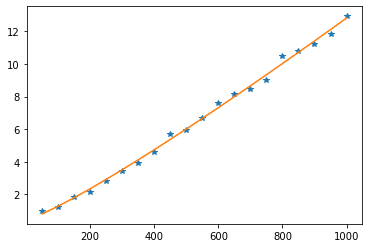

In [34]:
l_times_qs = []
a_timings=[]
for i in range(50, 1001, 50):
    print(i)
    t = np.random.permutation(i).astype(int)
    timings = %timeit -n 50 -r 5 -o -q qsort_5(t)
    l_times_qs.append([len(t), timings.best])
a_timings = np.array(l_times_qs)
print(a_timings)

fitted_timings = fit_func_2_times(a_timings, n_logn)
_ = plt.plot(a_timings[ : , 0], a_timings[ : , 1]/a_timings[0, 1], '*', a_timings[ : , 0], fitted_timings, '-')

In [29]:
def fit_func_2_times(timings: np.ndarray, func_2_fit: Callable):
    """Ajusta linealmente los valores de la funcion func_2_fit a
    los tiempos en timings.
    Esto es, calculamos valores a, b para que la funcion a*f(dim) + b
    se ajuste a los tiempos medidos.
    """
    try:
        if len(timings.shape) == 1:
            timings = timings.reshape(-1, 1)
        values = func_2_fit(timings[ :, 0]).reshape(-1, 1)

        #normalizar timings
        times = timings[ : , 1] / timings[0, 1]

        #ajustar a los valores en times un modelo lineal sobre los valores en values
        lr_m = LinearRegression()
        lr_m.fit(values, times)
    except:
        print("Error in funct fit func 2 times")
    else:
        return lr_m.predict(values)

def n_logn(n):
    return n*np.log(n)

In [19]:
def edit_distance(str_1: str, str_2: str)-> int:
    if len(str_1) == 0 or len(str_2) == 0:
        return None
    c = 0
    try:
        if len(str_1) < len(str_2):
            for i in range(0, len(str_1)):
                if str_1[i] != str_2[i]:
                    c += 1
            c += len(str_2) - len(str_1)
        else:
            for i in range(0, len(str_2)):
                if str_1[i] != str_2[i]:
                    c += 1
            c += len(str_1) - len(str_2)
    except:
        print("Error in funct edit distance")
    else:
        return c    

In [20]:
str_1='bahamasa'
str_2='bananas'
c=edit_distance(str_1, str_2)
print(c)

3


In [3]:
def max_subsequence_length(str_1: str, str_2: str)->int:
    
    e = np.zeros((len(str_1)+1, len(str_2)+1), dtype=int)
    try:
        for i in range(1, len(str_1)+1):
            for j in range(i, len(str_2)+1):
                if (str_1[i-1] == str_2[j-1]):
                    e[i,j] = 1 + e[i-1, j-1]
                else :
                    e[i, j] = max(e[i-1, j], e[i, j-1])
    except:
        print("Error in funct max subsequence length")
    else:
        return e[-1,-1]


In [4]:
y = "algoritmo"
x = "logaritmo"

e = max_subsequence_length(y, x)
print(e)

6


In [47]:
def max_common_subsequence(str_1: str, str_2: str)-> str:
    aux = []
    k=0
    try:
        for i in range(0, len(str_1)):
            for j in range(k, i+1):
                if str_1[i] == str_2[j]:
                    aux.append(str_1[i])
                    k = j
                    break
    except:
        print("Error in funct max common subsequence")
    else:
        return aux

In [48]:
x = "algoritmo"
y = "logaritmo"

e = max_common_subsequence(x, y)
print(e)

['l', 'g', 'r', 'i', 't', 'm', 'o']
